# HOMEWORK 7

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW7

In this homework you are going to rectify a document image that suffers from severe distortion. You will be using the same image and the same detected corners from the previous lesson (lesson 6).

Remember, OpenCV documentation is your friend ;-)

At the end of this notebook, there are a couple of questions for you to answer.

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input images
hm_version = 7

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone images
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Computer Vision/Practical_tasks/temp'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 4.62 KiB | 4.62 MiB/s, done.


Let's load the image we will be working on in this homework.

In [3]:
# Load data

import cv2
from pathlib import Path
import apps.reporter as rpt

# Input data
file_name = "resources/images/document.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(403, 302, 3)"


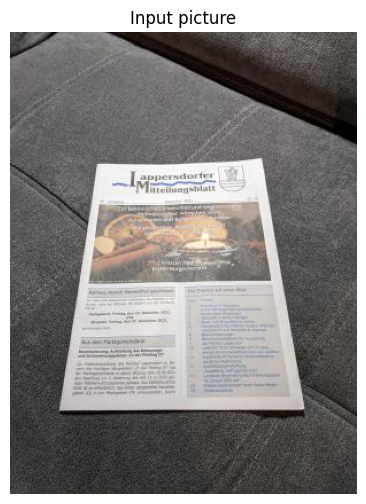

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Input picture")
plt.show()


In [9]:
# Homework 6 (cleaned)

import cv2
import numpy as np

# Input data
blockSize = 2
ksize = 3
k = 0.04
float_min_th = 1e-6
cornerness_th = -7

sign_color = (255, 0, 0)
float_min = np.finfo(np.float32).min
th_top_left, th_top_right = float_min, float_min
th_bottom_left, th_bottom_right = float_min, float_min
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None
quad_size = 7

# Solution
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
rows, cols = gray.shape
gray_n = gray.astype(np.float32) / 255
cornerness = cv2.cornerHarris(gray_n, blockSize=blockSize, ksize=ksize, k=k)
cornerness_ng = np.where(cornerness < float_min_th, float_min_th, cornerness)
cornerness_lg = np.log(cornerness_ng)
cornerness_lg_min = np.min(cornerness_lg)
cropped_cornerness = np.where(cornerness_lg < cornerness_th, cornerness_lg_min, cornerness_lg)

for r in range(quad_size, rows - quad_size):
    for c in range(quad_size, cols - quad_size):
        if cropped_cornerness[r, c] < cornerness_th:
            continue

        block = gray[r - quad_size:r + quad_size + 1, c - quad_size:c + quad_size + 1]
        height, width = block.shape
        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[0:quad_size, width - quad_size:width]
        quad_bottom_left = block[height - quad_size:height, 0:quad_size]
        quad_bottom_right = block[height - quad_size:height, width - quad_size:width]
        mean_top_left = np.mean(quad_top_left)
        mean_top_right = np.mean(quad_top_right)
        mean_bottom_left = np.mean(quad_bottom_left)
        mean_bottom_right = np.mean(quad_bottom_right)
        mean_sum = mean_top_left + mean_top_right + mean_bottom_left + mean_bottom_right
        # Top-left corner
        descriptor = 2 * mean_bottom_right - mean_sum
        if descriptor > th_top_left:
            th_top_left = descriptor
            opt_top_left = (c, r)
        # Top-right corner
        descriptor = 2 * mean_bottom_left - mean_sum
        if descriptor > th_top_right:
            th_top_right = descriptor
            opt_top_right = (c, r)
        # Bottom-left corner
        descriptor = 2 * mean_top_right - mean_sum
        if descriptor > th_bottom_left:
            th_bottom_left = descriptor
            opt_bottom_left = (c, r)
        # Bottom-right corner
        descriptor = 2 * mean_top_left - mean_sum
        if descriptor > th_bottom_right:
            th_bottom_right = descriptor
            opt_bottom_right = (c, r)

img_out = img_rgb.copy()
opts = [
    opt_top_left,
    opt_top_right,
    opt_bottom_left,
    opt_bottom_right,
]

for opt in opts:
    if opt is not None:
        img_out = cv2.circle(img_out, opt, 3, sign_color, -1)

# Print results
images_dict = {
    "Original image": img_rgb,
    "Grayscale image": gray_n,
    "Cornerness by Harris": cornerness,
    "Logarithmic cornerness": cornerness_lg,
    "Cropped cornerness": cropped_cornerness,
    "Image with detected corners": img_out,
}


[(76, 115), (219, 111), (43, 330), (256, 329)]


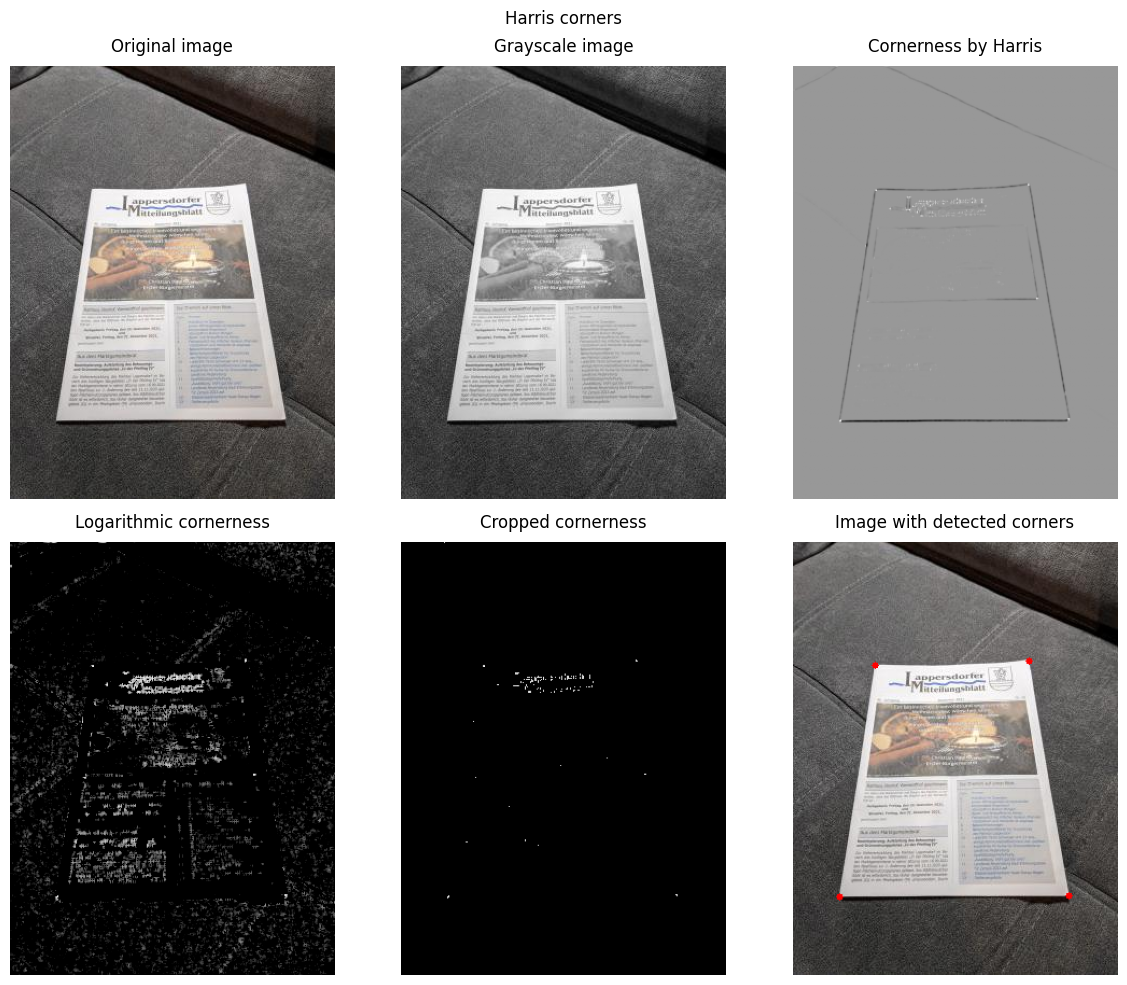

In [8]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 3
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Harris corners")
plt.tight_layout()
plt.show()


In the previous homework you should have detected the four document corners and you will need to use them here. But don't worry if the previous homework did not work out for you, I am going to provide you with the corners coordinates here :-)

### Document Rectification

Let's now try to rectify the document. The goal is to bring the four document corners to the image corners. For instance, we want the top-left document corner to become (0, 0), i.e., the top-left corner of the image itself. In that way, we will fill the complete image with document information and we will throw away parts of the images that correspond to background (which are of no use to us).

In [ ]:
# Define the matrix of source points corresponding to the 4 document corners.
# The matrix shall have shape (4, 2), i.e., 4 corners x 2 coordinates
# Note: You will need to explicitly use float32 data type
src = np.array(..., dtype=np.float32)

# Define the matrix of target (destination) points corresponding to the 4 image corners.
# The matrix shall have shape (4, 2), i.e., 4 corners x 2 coordinates
# Note: You will need to explicitly use float32 data type
# Note2: The order of points in src and dst must be the same
dst =

Let's first start with the affine transform for document rectification. The affine transform can be analytically calculated using 3 point pairs. Therefore, let's select the **first 3 points** and calculate the correspnding transfrom. We will then use the transform to rectify the document.

In [ ]:
# Compute the affine transform matrix (you'll have to use getAffineTransform function from OpenCV here)
# Use the first 3 points from your src and dst matrix
M =

# Build the rectified image using the computed matrix (you'll have to use warpAffine function from OpenCV here)
rectified =

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

Well, this is not bad by certainly not what we were aiming for. Let's try the **last 3** points instead.

In [ ]:
# Compute the affine transform matrix (use getAffineTransform)
# Use the last 3 points from your src and dst matrix
M =

# Build the rectified image using the computed matrix (use warpAffine)
rectified =

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

The result looks different but not better. This approach doesn't seem to be helping then. Let's use **all 4 points** and let OpenCV **estimate** (remember that 4 points are too many for an analytical solution) the best fitting affine transform for us. It'll internally apply optimization approaches as well as RANSAC.

In [ ]:
# Estimate the optimal affine transform matrix (you'll have to use estimateAffine2D function from OpenCV here)
# estimateAffine2D it returns the best fitting affine matrix as well as the vector of inliers (1 -> inlier,
# 0 -> outlier).
M, inliers =

# Build the rectified image using the computed matrix (use warpAffine)
rectified =

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

There is not much of an improvement either. Let's try homography instead of affine transform. Remember that for computing the homography analytically we need to use 4 pairs of points.

In [ ]:
# Compute the homography matrix (you'll have to use getPerspectiveTransform function from OpenCV here)
M =

# Build the rectified image using the computed matrix (you'll have to use warpPerspective function from OpenCV)
rectified =

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

### Questions
* The affine transform does not seem to be working well in this case. Why?
* What can you tell me about the values you have obtained for the inliers vector? What does it mean?
* How does the result from homography look? Does it work well enough? 

Remember, I am **not** looking for a particular answer. I want to see how you think, so be creative ;-)